In [ ]:
import pickle
import warnings
import random
import colorsys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.transforms as transforms
from matplotlib.ticker import MultipleLocator
from scipy.stats import mannwhitneyu

from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    accuracy_score, precision_score, recall_score, confusion_matrix, balanced_accuracy_score
)
from scipy.stats import entropy

warnings.filterwarnings('ignore')

In [ ]:
X = pd.read_csv(
    '/bgi-seq-model-2/datasets/zhangkexin/meta_index/metaphlan4/fine-tune/curated_LiS_CRC_20204_v1121.train_test.profile',
    sep='\t', index_col=0).transpose()
index = []
for i in range(len(X.axes[1])):
    if X.columns[i].split('|')[-1].split('__')[0] == 's':
        index.append(i)
X = X.iloc[:, index]
X.columns = [i.split('|')[-1].replace('__', '-').replace(' ', '-').replace('_', '-').lower() for i in X.columns]

In [2]:
def calculate_mndi_v2(individual_network, sample_list, taxa2id,
                      case_samples, ctrl_samples,
                      bad_taxa, good_taxa):
    """
    individual_network: (n_sample, n_taxa, n_taxa)
    """
    # 1. 索引准备
    bad_idx = [taxa2id[t] for t in bad_taxa if t in taxa2id]
    good_idx = [taxa2id[t] for t in good_taxa if t in taxa2id]
    bad_list = [t for t in bad_taxa if t in taxa2id]
    good_list = [t for t in good_taxa if t in taxa2id]

    mndi_features = []

    for i in range(individual_network.shape[0]):
        sample_feature_dict = {'sample_id': sample_list[i]}
        # 获取当前样本的邻接矩阵 (|cosine| > 0 或设定阈值)
        # 假设原始数据是 correlation，转为二值或权重图
        adj = np.abs(individual_network[i])
        # adj = individual_network[i]
        adj[np.isnan(adj)] = 0  # 处理空值

        # ---------------要是看边数的话
        # threshold = 0
        # adj = (adj > threshold).astype(float)

        np.fill_diagonal(adj, 0)

        # 特征 A: 坏菌内部相互作用总和 (Bad-Bad)
        bad_internal = adj[np.ix_(bad_idx, bad_idx)].sum() / 2

        # 特征 B: 坏菌与全网的相互作用 (Bad-All)
        bad_all = adj[bad_idx, :].sum()

        # 特征 C: 好菌与全网的相互作用 (Good-All)
        good_internal = adj[np.ix_(good_idx, good_idx)].sum() / 2
        good_all = adj[good_idx, :].sum()
        bad_good_internal = adj[np.ix_(bad_idx, good_idx)].sum()

        # 特征 D: 全网总连接
        total_edges = adj.sum() / 2

        sample_feature_dict.update({
            'f_bad_bad': bad_internal,
            'f_bad_all': bad_all,
            'f_bad_dominance': bad_all / (total_edges + 1e-5),
            'f_good_good': good_internal,
            'f_good_all': good_all,
            'f_good_dominance': good_all / (total_edges + 1e-5),
            'f_total_edges': total_edges,
            'f_tmp': (bad_internal + 1e-5) / (good_internal + 1e-5),
            'f_bad_good_internal': bad_good_internal,
            # 'f_bad_good_internal': (bad_internal - good_internal) / (good_internal + bad_internal + 1e-5),
            'f_good_loss': 1 / (good_all + 1e-5)
        })

        mndi_features.append(sample_feature_dict)

    df_features = pd.DataFrame(mndi_features)
    df_features['group'] = df_features['sample_id'].apply(lambda x: 'case' if x in case_samples else 'ctrl')

    df_features['MNDI'] = np.log10(df_features['f_tmp'] + 1e-5)

    return df_features

In [3]:
def generate_random_colors(n=100, seed=111):
    random.seed(seed)
    colors = []
    for _ in range(n):
        h = random.random()
        s = random.uniform(0.2, 0.6)  # 低饱和度
        v = random.uniform(0.8, 1.0)  # 高明度
        r, g, b = colorsys.hsv_to_rgb(h, s, v)
        colors.append((r, g, b))

    colors_hex = [
        '#{:02x}{:02x}{:02x}'.format(int(r * 255), int(g * 255), int(b * 255))
        for r, g, b in colors
    ]
    sns_palette = sns.color_palette(colors_hex)
    return sns_palette

In [9]:
def plot_disease_case_ctrl_mndi_split_rows(df_features, label_df):
    target_diseases = ['IBD', 'IBS', 'adenoma', 'CRC', 'melanoma', 'T2D', 'metabolic_syndrome', 'OB', 'IGT', 'BL', 'others', 'AS', 'ACVD', 'CKD', 'COVID-19']
    display_map = {
        'adenoma': 'Adenoma',
        'melanoma': 'Melanoma',
        'metabolic_syndrome': 'MS',
        'others': 'Others'
    }
    # --- 1. 数据预处理与同队列匹配 (Project-Matched) ---
    label_df['sample_id'] = list(label_df.index)

    def map_disease(d):
        d_str = str(d)
        if d_str.lower() == 'healthy':
            return 'Healthy'
        elif d_str in target_diseases:
            return d_str
        else:
            return 'others'

    label_df['disease_united'] = label_df['disease_united'].apply(map_disease)

    # 合并特征和标签
    merged_df = pd.merge(df_features, label_df[['sample_id', 'disease_united', 'project']], on='sample_id', how='left')
    # 获取除了 Healthy 之外的所有疾病列表
    all_diseases = [d for d in merged_df['disease_united'].dropna().unique() if d != 'Healthy']
    diseases = [d for d in target_diseases if d in all_diseases]

    plot_rows = []
    for d in diseases:
        projs_with_disease = merged_df[merged_df['disease_united'] == d]['project'].unique()
        matched_subset = merged_df[merged_df['project'].isin(projs_with_disease)].copy()
        matched_subset = matched_subset[matched_subset['disease_united'].isin([d, 'Healthy'])].copy()
        matched_subset['plot_disease'] = d
        matched_subset['plot_group'] = matched_subset['disease_united'].apply(
            lambda x: 'ctrl' if x == 'Healthy' else 'case')
        if matched_subset['plot_group'].nunique() == 2:
            y_true = (matched_subset['group'] == 'case').astype(int)
            fpr, tpr, thresholds = roc_curve(y_true, matched_subset['MNDI'])
            roc_auc = auc(fpr, tpr)
            print(f"{d} AUC: {roc_auc:.4f}")
        plot_rows.append(matched_subset)
    plot_df = pd.concat(plot_rows, ignore_index=True)
    plot_df['plot_disease'] = plot_df['plot_disease'].apply(lambda x: display_map.get(x, x))
    
    # 同步把用于控制排序的 diseases 列表也映射过去
    display_diseases = [display_map.get(d, d) for d in diseases]
    
    # --- 2. 计算各组独立的样本量并构造拆分的 Y 轴标签 ---
    # 分别计算 Case 和 Ctrl 各自的数量
    counts = plot_df.groupby(['plot_disease', 'plot_group']).size().reset_index(name='n')
    plot_df = pd.merge(plot_df, counts, on=['plot_disease', 'plot_group'])

    # 核心修改：为 Case 和 Ctrl 生成独立的一行标签
    # 加上疾病前缀防止不同疾病的 Ctrl 标签重名导致箱线图重叠
    def make_label(row):
        if row['plot_group'] == 'case':
            return f"{row['plot_disease']} | case (n={row['n']})"
        else:
            return f"{row['plot_disease']} | ctrl (n={row['n']})"
        
    plot_df['y_label'] = plot_df.apply(make_label, axis=1)
    plot_df['plot_group'] = pd.Categorical(plot_df['plot_group'], categories=['case', 'ctrl'], ordered=True)
    plot_df['plot_disease'] = pd.Categorical(plot_df['plot_disease'], categories=display_diseases, ordered=True)
    plot_df = plot_df.sort_values(['plot_disease', 'plot_group'])
    
    y_order = list(plot_df['y_label'].unique())
    unique_diseases = list(plot_df['plot_disease'].unique())

    # --- 3. 绘图初始化 ---
    fig, ax = plt.subplots(figsize=(12, len(y_order) * 0.7), facecolor='white')
    plt.rc('font', size=22)
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['axes.linewidth'] = 2.0  # 全局设置边框粗细为 2.0
    plt.rcParams['pdf.fonttype'] = 42
    sns.set_style("ticks")
    ax.set_facecolor('white')
    color_map = {'case': '#e74c3c', 'ctrl': '#3498db'}
    custom_palette = generate_random_colors(len(y_order), seed=101)
    # --- 4. 绘制按疾病交替的斑马纹背景 ---
    # 核心逻辑：找到同一个疾病占据的行索引区间，统一画一个大的灰色方块
    trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)
    
    for i, d in enumerate(unique_diseases):
        indices = [idx for idx, label in enumerate(y_order) if label.startswith(f"{d} |")]
        if i % 2 == 0 and indices:
            start_y = min(indices) - 0.5
            height = max(indices) - min(indices) + 1 
            rect = plt.Rectangle((-0.65, start_y), 1.65, height,
                                 transform=trans, color='lightgray', alpha=0.5, # 增加一点透明度对比
                                 zorder=0, clip_on=False)
            ax.add_patch(rect)
    # --- 5. 绘制图形 ---
    # 核心修改：dodge=False。因为每一行现在只对应唯一的一组数据，不需要并排挤在一起
    # sns.boxplot(
    #     data=plot_df, x='MNDI', y='y_label', hue='plot_group', fliersize=4,
    #     flierprops={'marker': 'o', 'markerfacecolor': 'black', 'markeredgecolor': 'black', 'markersize': 4, 'alpha': 0.7},
    #     order=y_order, palette=color_map, dodge=False, width=0.6, ax=ax, zorder=2, linewidth=2,
    #     boxprops={'edgecolor': '#333333'},               
    #     whiskerprops={'color': '#333333', 'linewidth': 1.5}, 
    #     medianprops={'color': '#333333', 'linewidth': 3}
    # )
    # sns.stripplot(
    #     data=plot_df, x='MNDI', y='y_label', hue='plot_group', palette=['#333333', '#333333'],
    #     alpha=0.3, size=3, jitter=True, dodge=False, ax=ax, zorder=3, legend=False
    # )
    # sns.boxplot(
    #     data=plot_df, x='MNDI', y='y_label', hue='y_label',
    #     order=y_order, palette=custom_palette, dodge=False, width=0.5, fliersize=0, ax=ax, zorder=2,
    #     legend=False # 关闭自动生成的庞大图例
    # )
    # 1. 绘制底层小提琴图 (内部留空)
    def filter_extreme(group):
        q_low = group['MNDI'].quantile(0.00001)  # 砍掉下限最极端的 1%
        q_high = group['MNDI'].quantile(0.99999) # 砍掉上限最极端的 1%
        return group[(group['MNDI'] >= q_low) & (group['MNDI'] <= q_high)]

    violin_df = plot_df.groupby('y_label', group_keys=False).apply(filter_extreme)
    v=sns.violinplot(
        data=violin_df, x='MNDI', y='y_label', hue='y_label',
        order=y_order, palette=custom_palette, dodge=False, color='#333333',
        inner=None, linewidth=1.5, cut=0, ax=ax, zorder=2, legend=False, bw_adjust=0.8
    )
    for pc in v.collections:
        pc.set_edgecolor('#333333')  # 强制边框颜色
        pc.set_alpha(1)              # 确保边框是不透明的


    # 2. 叠加内部的迷你箱线图
    sns.boxplot(
        data=violin_df, x='MNDI', y='y_label', 
        order=y_order, dodge=False, 
        width=0.3,                # 🌟 把箱子调得很窄，刚好放在小提琴内部
        color='white',            # 箱体填充白色
        linewidth=1.5,            # 箱体外边框粗细
        fliersize=4,              # 隐藏离群点（避免和后面的散点图重复）
        flierprops={'marker': 'o', 'markerfacecolor': 'black', 'markeredgecolor': 'black', 'markersize': 4, 'alpha': 0.7},
        showcaps=False,           # 隐藏胡须末端的横线，使其更清爽
        ax=ax, zorder=3,
        boxprops={'edgecolor': '#333333'},               # 箱体边框颜色
        whiskerprops={'color': '#333333', 'linewidth': 1.5}, # 上下须的颜色和粗细
        medianprops={'color': '#a82315', 'linewidth': 3}     # 🌟 核心：中位线加粗！
    )

    # 3. 叠加抖动散点图 (放在最上层)
    # sns.stripplot(
    #     data=plot_df, x='MNDI', y='y_label', hue='y_label', palette=custom_palette,
    #     alpha=0.4, size=3.5, jitter=True, dodge=False, ax=ax, zorder=4, legend=False
    # )
    # --- 6. P值计算与标注居中 ---
    x_max = plot_df['MNDI'].max()
    x_max = 2
    # annotation_x = x_max * 1.05
    annotation_x = x_max + 0.8
    
    stats_results = []
    for d in unique_diseases:
        # 获取该疾病所在行的索引，用于将 P 值标注放在两行的正中间
        indices = [idx for idx, label in enumerate(y_order) if label.startswith(f"{d} |")]
        y_pos = sum(indices) / len(indices)
        disease_data = plot_df[plot_df['plot_disease'] == d]
        case_vals = disease_data[disease_data['plot_group'] == 'case']['MNDI']
        ctrl_vals = disease_data[disease_data['plot_group'] == 'ctrl']['MNDI']
        
        n_case = len(case_vals)
        n_ctrl = len(ctrl_vals)
        mndi_p_val = None
        shannon_p_val = None
        mndi_auc_val = None
        shannon_auc_val = None
        
        # 🌟 新增：提取 Shannon 数据用于辅助检验
        case_shannon = disease_data[disease_data['plot_group'] == 'case']['shannon'].dropna()
        ctrl_shannon = disease_data[disease_data['plot_group'] == 'ctrl']['shannon'].dropna()
        
        # 如果缺胳膊少腿（没有Case或没有Ctrl），按要求输出 '—'
        stars = "—"
        star_color = '#333333'
        
        if len(case_vals) > 0 and len(ctrl_vals) > 0:
            stat, p_val = mannwhitneyu(case_vals, ctrl_vals)
            mndi_p_val = p_val
            # 🌟 新增：计算 MNDI 的 AUC
            y_true_mndi = [1] * n_case + [0] * n_ctrl
            y_score_mndi = list(case_vals) + list(ctrl_vals)
            fpr_m, tpr_m, _ = roc_curve(y_true_mndi, y_score_mndi)
            mndi_auc_val = auc(fpr_m, tpr_m)
        
            if len(case_shannon) > 0 and len(ctrl_shannon) > 0:
                _, shannon_p = mannwhitneyu(case_shannon, ctrl_shannon)
                shannon_p_val = shannon_p
                y_true_shan = [1] * len(case_shannon) + [0] * len(ctrl_shannon)
                y_score_shan = list(case_shannon) + list(ctrl_shannon)
                fpr_s, tpr_s, _ = roc_curve(y_true_shan, y_score_shan)
                shannon_auc_val = auc(fpr_s, tpr_s)
                shannon_auc_val = max(shannon_auc_val, 1 - shannon_auc_val)
                
                # 当 MNDI 显著 (p<0.05) 且 Shannon 不显著 (p>=0.05) 时，将星号标红
                if p_val < 0.05 and shannon_p >= 0.05:
                    star_color = '#a82315'
                elif p_val < shannon_p:
                    star_color = '#e74c3c'

            if p_val < 0.001:
                stars = '***'
            elif p_val < 0.01:
                stars = '**'
            elif p_val < 0.05:
                stars = '*'
            else:
                stars = ' '
    
        # 添加标注，y_pos 会自动位于 Case 和 Ctrl 行的中间
        ax.text(annotation_x, y_pos, stars, va='center', ha='center',
                fontsize=20, fontweight='bold', color=star_color)   
                
        stats_results.append({
            'disease': d,
            'n_case': n_case,
            'n_ctrl': n_ctrl,
            'MNDI_pvalue': mndi_p_val,
            'MNDI_AUC': mndi_auc_val,           # <-- 新加这行
            'Shannon_pvalue': shannon_p_val,
            'Shannon_AUC': shannon_auc_val      # <-- 新加这行
        })

    # --- 7. 美化与保存 ---
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.tick_params(axis='y', labelsize=22)  # 调节 Y 轴疾病标签的字体大小
    ax.tick_params(axis='x', labelsize=22)  # 调节 X 轴数字的字体大小
    plt.xlabel('MNDI Score', fontsize=24)
    plt.ylabel('')
    # 自定义图例
    # case_patch = mpatches.Patch(color='#e74c3c', label='Disease')
    # ctrl_patch = mpatches.Patch(color='#3498db', label='Healthy')
    # ax.legend(handles=[case_patch, ctrl_patch], title='Condition',
    #           bbox_to_anchor=(1.05, 1), loc='upper left')
    sns.despine()
    # plt.xlim(right=annotation_x * 1.1)
    plt.xlim(left=-2, right=annotation_x + 0.5)
    # plt.tight_layout()
    fig.subplots_adjust(left=0.35)  # 给较长的 Y 轴标签留出足够的左侧空间
    plt.savefig(f'/bgi-seq-model-2/codes/zhangkexin/meta_index/experiment/figures/finetune/11.25/networks/4.1/abs/pandisease.disease.case.ctrl.mndi.pdf',
                dpi=800, bbox_inches='tight')
    plt.show()
    
    
    # --- 8. 🌟 导出统计表格 ---
    stats_df = pd.DataFrame(stats_results)
    csv_save_path = '/bgi-seq-model-2/codes/zhangkexin/meta_index/experiment/figures/finetune/11.25/networks/4.1/abs/new.pandisease.disease.case.ctrl.stats1.tsv'
    stats_df.to_csv(csv_save_path, sep='\t', index=False)

--------PANDISEASE
AUC: 0.7084
Optimal MNDI Threshold: -0.0082
--- 分类性能评估 ---
Accuracy: 0.6779
Balanced Accuracy: 0.6646
Sensitivity (Sens): 0.6163
Specificity (Spec): 0.7129
Confusion Matrix: TP=845, FP=691, TN=1716, FN=526
IBD AUC: 0.7807
IBS AUC: 0.7227
adenoma AUC: 0.3669
CRC AUC: 0.5907
T2D AUC: 0.6179
metabolic_syndrome AUC: 0.6556
OB AUC: 0.7187
IGT AUC: 0.6872
BL AUC: 0.4657
others AUC: 0.5980
AS AUC: 0.5927
ACVD AUC: 0.6498
CKD AUC: 0.6870
COVID-19 AUC: 0.8286


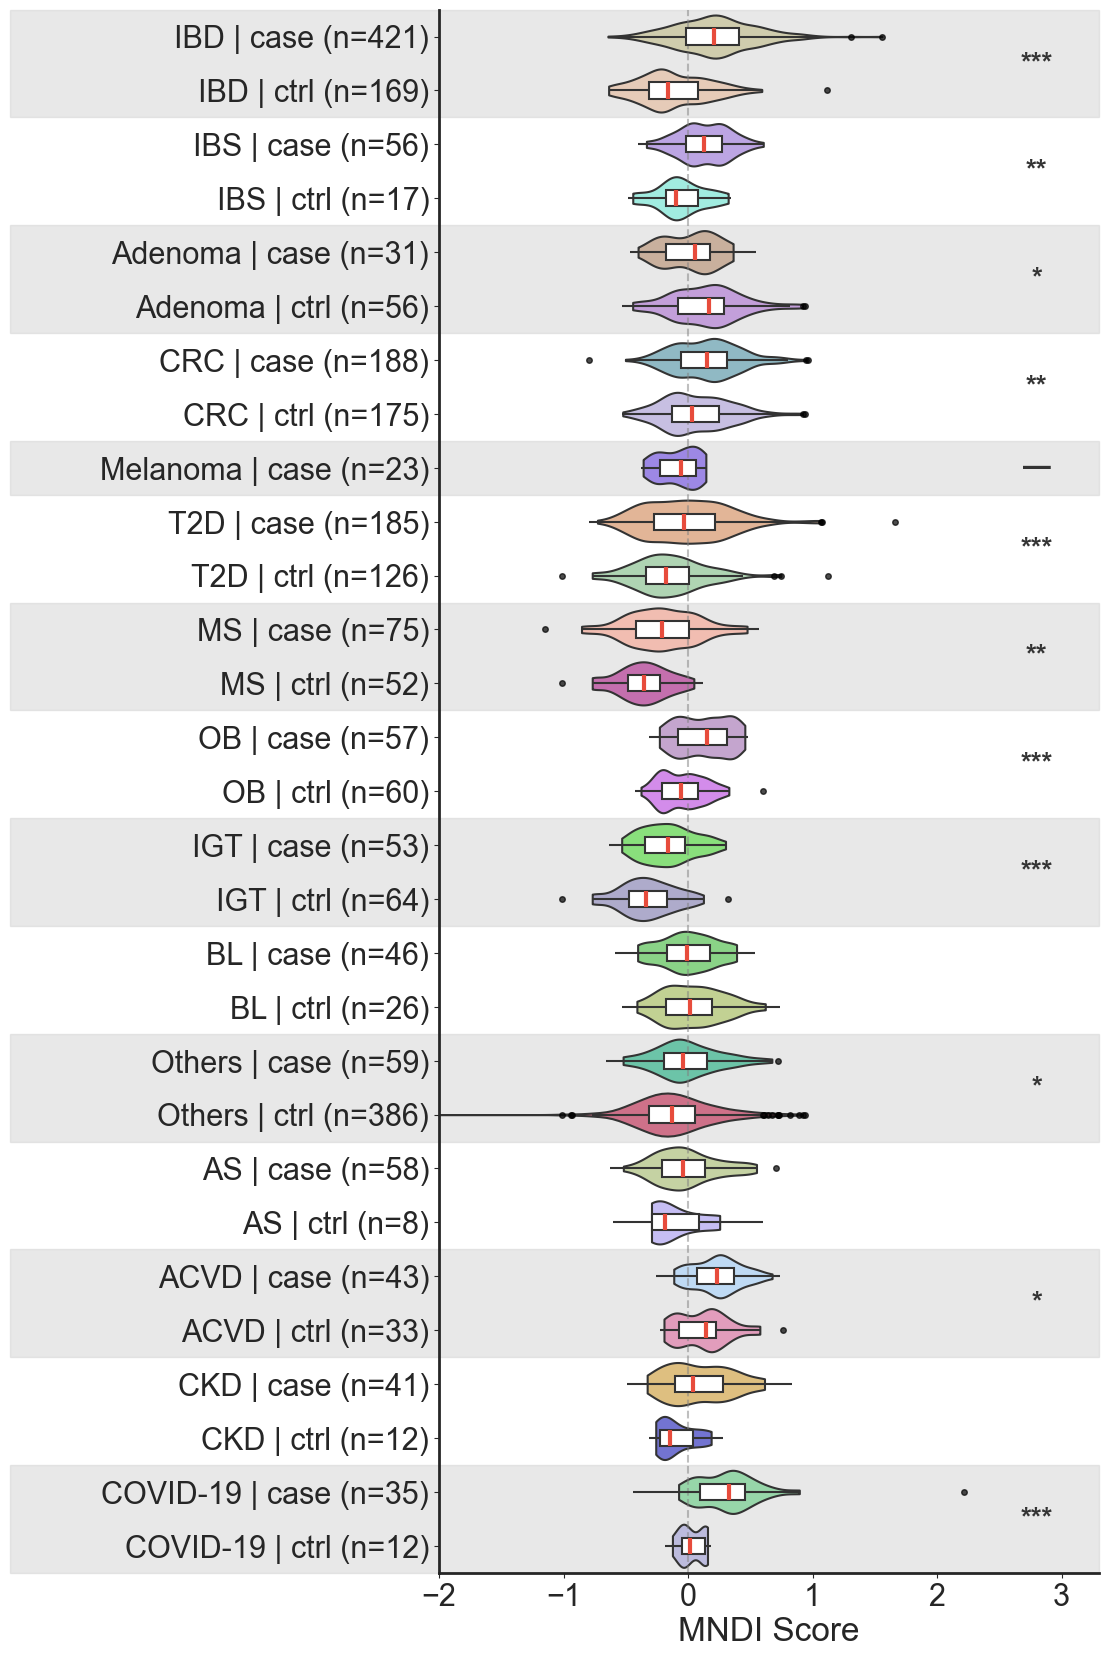

In [10]:
# pandisease
print('--------PANDISEASE')
dir = '/bgi-seq-model-2/codes/zhangkexin/meta_index/experiment/results/network/1.8/pandisease/'
sample_list = list(pd.read_csv(dir + 'pandisease.split1.valtest.samples.csv')['samples'])
label_df = pd.read_csv(
    '/bgi-seq-model-2/datasets/zhangkexin/meta_index/metaphlan4/fine-tune/curated_LiS_CRC_20204_v0908.train_test.phe',
    sep='\t', index_col=0)
case_samples = []
ctrl_samples = []
for i in sample_list:
    if label_df.loc[i, 'disease_united'] != 'healthy':
        case_samples.append(i)
    elif label_df.loc[i, 'disease_united'] == 'healthy':
        ctrl_samples.append(i)

individual_network = np.load(dir + 'pandisease.split1.valtest.pretrain.emb.cosine.individual.npy')
taxa2id = pickle.load(open(dir + 'pandisease.split1.valtest.pretrain.emb.cosine.individual.index.pkl', 'rb'))
# top20_good_biomarker = ['s-' + i.lower().replace(" ", "-") for i in
#                         list(pd.read_csv(dir + 'top20.negative.o2.csv', index_col=0).index)]
# top20_bad_biomarker = ['s-' + i.lower().replace(" ", "-") for i in
#                        list(pd.read_csv(dir + 'top20.positive.o2.csv', index_col=0).index)]
# top30_good_biomarker = ['s-' + i.lower().replace(" ", "-") for i in
#                         list(pd.read_csv(dir + 'top30.negative.o3.csv', index_col=0).index)]
# top30_bad_biomarker = ['s-' + i.lower().replace(" ", "-") for i in
#                        list(pd.read_csv(dir + 'top30.positive.o3.csv', index_col=0).index)]

pan_biomarker = pd.read_csv(
    '/bgi-seq-model-2/codes/zhangkexin/meta_index/experiment/results/features/11.25/sort.multidisease.mean/pandisease.biomarker.txt',
    sep='\t', header=None)
pan_biomarker['weight.abs'] = pan_biomarker[1].abs()
pan_biomarker = pan_biomarker.sort_values('weight.abs', ascending=False)
top30_good_biomarker = list(pan_biomarker[pan_biomarker[1] < 0].iloc[:, 0])
top30_bad_biomarker = list(pan_biomarker[pan_biomarker[1] > 0].iloc[:, 0])

df_features = calculate_mndi_v2(individual_network, sample_list, taxa2id,
                                case_samples, ctrl_samples,
                                top30_bad_biomarker, top30_good_biomarker)

# 加shannon
X_pandisease = X.loc[case_samples+ctrl_samples, :]

shannon_df = pd.DataFrame({
    'sample_id': X_pandisease.index,
    'shannon': X_pandisease.apply(lambda x: entropy(x[x > 0]), axis=1)
})
df_features = pd.merge(df_features, shannon_df, on='sample_id', how='left')

plot_disease_case_ctrl_mndi_split_rows(df_features, label_df)





In [23]:
# def plot_cohort_case_ctrl_mndi(df_features, label_df, disease, case_color, ctrl_color):
#     # --- 1. 数据整合与排序 ---
#     label_df['sample_id'] = list(label_df.index)
#     label_df['disease_united'] = ['Healthy' if i == 'healthy' else i for i in label_df['disease_united']]
#     # 注意：确保 label_df 中包含 'disease_united' 列
#     plot_df = pd.merge(df_features, label_df[['sample_id', 'project', 'disease_united']], on='sample_id', how='left')
#     # 强制转换 group 为分类变量并指定顺序，这决定了同一项目内的上下顺序
#     plot_df['group'] = pd.Categorical(plot_df['group'], categories=['case', 'ctrl'], ordered=True)
#     # 计算样本量 (按 project 和 disease_united 分组)
#     counts = plot_df.groupby(['project', 'disease_united']).size().reset_index(name='n')
#     plot_df = pd.merge(plot_df, counts, on=['project', 'disease_united'])
#     # --- 核心修改：构造 Y 轴标签 ---
#     # 格式：Project | Disease (n=xx)
#     plot_df['y_label'] = plot_df.apply(
#         lambda x: f"{x['project']} | {x['disease_united']} (n={x['n']})", axis=1
#     )
#     # 排序：先按项目名排，再按 group 排 (确保 Case 在上面)
#     plot_df = plot_df.sort_values(['project', 'group'])
#     y_order = list(plot_df['y_label'].unique())
#     projects = plot_df['project'].unique()
#     # --- 2. 绘图初始化 ---
#     fig, ax = plt.subplots(figsize=(12, len(y_order) * 0.7))
#     plt.rc('font', size=22)
#     plt.rcParams['font.family'] = 'Arial'
#     plt.rcParams['axes.linewidth'] = 2.0  # 全局设置边框粗细为 2.0
#     plt.rcParams['pdf.fonttype'] = 42
#     sns.set_style("ticks")
#     # --- 核心修改：图例颜色映射 ---
#     # 自动获取所有疾病名称并分配颜色（Healthy 用蓝色，其他疾病用不同色调的红色/橘色）
#     unique_diseases = plot_df['disease_united'].unique()
#     # color_map = {}
#     # for d in unique_diseases:
#     #     if 'healthy' in d.lower() or 'ctrl' in d.lower() or 'control' in d.lower():
#     #         color_map[d] = '#b6dafd'  # 蓝色
#     #     else:
#     #         color_map[d] = '#ed91bb'  # 红色
#     color_map = {}
#     for label in y_order:
#         # 根据 label_df 中的 group 分配颜色
#         # 因为 y_label 是唯一的，我们可以反查这一行是 case 还是 ctrl
#         current_group = plot_df[plot_df['y_label'] == label]['group'].iloc[0]
#         if current_group == 'case':
#             color_map[label] = case_color  # 红色
#         else:
#             color_map[label] = ctrl_color  # 蓝色
#     # custom_palette = generate_random_colors(len(unique_diseases), seed=101)
#     # --- 3. 绘制背景色块 ---
#     trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)
#     for i, proj in enumerate(projects):
#         if i % 2 == 0:
#             proj_labels = [label for label in y_order if label.startswith(proj)]
#             indices = [y_order.index(l) for l in proj_labels]
#             if indices:
#                 start_y, end_y = min(indices) - 0.5, max(indices) + 0.5
#                 rect = plt.Rectangle((-0.8, start_y), 1.8, end_y - start_y,
#                                      transform=trans, color='lightgray', alpha=0.5,
#                                      zorder=0, clip_on=False)
#                 ax.add_patch(rect)
#     # --- 4. 绘制图形 (hue 使用 disease_united) ---
#     # sns.boxplot(
#     #     data=plot_df, x='MNDI', y='y_label', hue='disease_united',
#     #     order=y_order, palette=color_map, dodge=False, width=0.6, fliersize=0, ax=ax, zorder=2
#     # )
#     # sns.stripplot(
#     #     data=plot_df, x='MNDI', y='y_label', color='black',
#     #     alpha=0.2, size=3, jitter=True, ax=ax, zorder=3
#     # )
#     # def filter_extreme(group):
#     #     q_low = group['MNDI'].quantile(0.00001)  # 砍掉下限最极端的 1%
#     #     q_high = group['MNDI'].quantile(0.99999) # 砍掉上限最极端的 1%
#     #     return group[(group['MNDI'] >= q_low) & (group['MNDI'] <= q_high)]
#     #
#     # violin_df = plot_df.groupby('y_label', group_keys=False).apply(filter_extreme)
#     v = sns.violinplot(
#         data=plot_df, x='MNDI', y='y_label', hue='y_label',
#         order=y_order, palette=color_map, dodge=False, color='#333333',
#         inner=None, linewidth=1.5, cut=0, ax=ax, zorder=2, legend=False, bw_adjust=0.8
#     )
#     for pc in v.collections:
#         pc.set_edgecolor('#333333')  # 强制边框颜色
#         pc.set_alpha(1)  # 确保边框是不透明的
#     # 2. 叠加内部的迷你箱线图
#     sns.boxplot(
#         data=plot_df, x='MNDI', y='y_label',
#         order=y_order, dodge=False,
#         width=0.3,  # 🌟 把箱子调得很窄，刚好放在小提琴内部
#         color='white',  # 箱体填充白色
#         linewidth=1.5,  # 箱体外边框粗细
#         fliersize=4,  # 隐藏离群点（避免和后面的散点图重复）
#         flierprops={'marker': 'o', 'markerfacecolor': 'black', 'markeredgecolor': 'black', 'markersize': 4,
#                     'alpha': 0.7},
#         showcaps=False,  # 隐藏胡须末端的横线，使其更清爽
#         ax=ax, zorder=3,
#         boxprops={'edgecolor': '#333333'},  # 箱体边框颜色
#         whiskerprops={'color': '#333333', 'linewidth': 1.5},  # 上下须的颜色和粗细
#         medianprops={'color': '#e74c3c', 'linewidth': 3}  # 🌟 核心：中位线加粗！
#     )
#     # --- 5. P值计算与标注 ---
#     x_max = plot_df['MNDI'].max()
#     annotation_x = x_max * 1.05
#     # --- 5. P值计算与标注 ---
#     x_max = plot_df['MNDI'].max()
#     annotation_x = x_max * 1.05
#     for proj in projects:
#         # 获取该项目所在行的索引，自动计算出正中间的 Y 坐标
#         indices = [idx for idx, label in enumerate(y_order) if label.startswith(f"{proj} |")]
#         if not indices: continue
#         y_pos = sum(indices) / len(indices)
#         proj_data = plot_df[plot_df['project'] == proj]
#         case_vals = proj_data[proj_data['group'] == 'case']['MNDI']
#         ctrl_vals = proj_data[proj_data['group'] == 'ctrl']['MNDI']
#         # 默认缺组（没有Case或Ctrl）输出 '—'
#         stars = "—"
#         if len(case_vals) > 0 and len(ctrl_vals) > 0:
#             stat, p_val = mannwhitneyu(case_vals, ctrl_vals)
#             if p_val < 0.001:
#                 stars = '***'
#             elif p_val < 0.01:
#                 stars = '**'
#             elif p_val < 0.05:
#                 stars = '*'
#             else:
#                 stars = ''  # 不显著就不标，或者你可以改成 'ns'
#         # 添加标注
#         if stars:
#             ax.text(annotation_x, y_pos, stars, va='center', ha='center',
#                     fontsize=20, fontweight='bold', color='#333333')
#     # --- 6. 美化与保存 ---
#     plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
#     # plt.title('MNDI Distribution by Disease Type', fontsize=14, pad=20)
#     ax.tick_params(axis='y', labelsize=22)  # 调节 Y 轴疾病标签的字体大小
#     ax.tick_params(axis='x', labelsize=22)  # 调节 X 轴数字的字体大小
#     plt.xlabel('MNDI Score', fontsize=24)
#     plt.ylabel('')
#     # --- 核心修改：自定义图例 ---
#     # 手动创建两个代表 Disease 和 Healthy 的色块，颜色与你的前面设定的保持一致
#     # disease_patch = mpatches.Patch(color='#e74c3c', label='Disease')
#     # healthy_patch = mpatches.Patch(color='#3498db', label='Healthy')
#     # # 覆盖默认图例
#     # plt.legend(handles=[disease_patch, healthy_patch], title='Condition',
#     #            bbox_to_anchor=(1.05, 1), loc='upper left')
#     sns.despine()
#     ax.xaxis.set_major_locator(MultipleLocator(1))
#     plt.xlim(right=annotation_x * 1.1)
#     fig.subplots_adjust(left=0.35)  # 预留左侧空间
#     save_path = f'/bgi-seq-model-2/codes/zhangkexin/meta_index/experiment/figures/finetune/11.25/networks/4.1/abs/{disease}.project.individual.case.ctrl.mndi.pdf'
#     plt.savefig(save_path, dpi=800, bbox_inches='tight')
#     plt.show()


In [40]:
def plot_hlevel_cohort_case_ctrl_mndi(df_features, label_df, disease, case_color, ctrl_color):
    # --- 1. 数据整合与排序 ---
    label_df = label_df.copy()
    label_df['sample_id'] = list(label_df.index)
    label_df['disease_united'] = ['Healthy' if str(i).lower() == 'healthy' else i for i in label_df['disease_united']]
    
    # 注意：确保 label_df 中包含 'disease_united' 列
    plot_df = pd.merge(df_features, label_df[['sample_id', 'project', 'disease_united']], on='sample_id', how='left')
    
    # 强制转换 group 为分类变量并指定顺序
    plot_df['group'] = pd.Categorical(plot_df['group'], categories=['case', 'ctrl'], ordered=True)
    
    # 计算样本量 (按 project 和 disease_united 分组)
    counts = plot_df.groupby(['project', 'disease_united']).size().reset_index(name='n')
    plot_df = pd.merge(plot_df, counts, on=['project', 'disease_united'])
    
    # --- 核心修改：构造 X 轴标签 ---
    # 格式：Project | Disease (n=xx)
    plot_df['x_label'] = plot_df.apply(
        lambda x: f"{x['project']} | {x['disease_united']} (n={x['n']})", axis=1
    )
    
    # 排序：先按项目名排，再按 group 排
    plot_df = plot_df.sort_values(['project', 'group'])
    x_order = list(plot_df['x_label'].unique())
    projects = plot_df['project'].unique()
    
    # --- 2. 绘图初始化 ---
    # 🌟 调整画板尺寸：宽度随条目数量变化，高度固定（留够底部空间给长标签）
    fig, ax = plt.subplots(figsize=(len(x_order) * 0.8, 10))
    plt.rc('font', size=22)
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['axes.linewidth'] = 2.0  # 全局设置边框粗细为 2.0
    plt.rcParams['pdf.fonttype'] = 42
    
    plt.rcParams['text.color'] = 'black'
    plt.rcParams['axes.labelcolor'] = 'black'
    plt.rcParams['xtick.color'] = 'black'
    plt.rcParams['ytick.color'] = 'black'
    
    sns.set_style("ticks")
    
    # --- 图例颜色映射 ---
    color_map = {}
    for label in x_order:
        current_group = plot_df[plot_df['x_label'] == label]['group'].iloc[0]
        if current_group == 'case':
            color_map[label] = case_color  # 红色 (或传入的 Case 颜色)
        else:
            color_map[label] = ctrl_color  # 蓝色 (或传入的 Ctrl 颜色)
            
    # --- 3. 绘制背景色块 (改为垂直色块) ---
    # 🌟 修改坐标系映射：X为数据坐标(柱子位置)，Y为轴坐标(0-1铺满高度)
    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    for i, proj in enumerate(projects):
        if i % 2 == 0:
            proj_labels = [label for label in x_order if label.startswith(proj)]
            indices = [x_order.index(l) for l in proj_labels]
            if indices:
                start_x, end_x = min(indices) - 0.5, max(indices) + 0.5
                # 🌟 画矩形：(起点X, 起点Y)，宽度，高度
                rect = plt.Rectangle((start_x, -0.9), end_x - start_x, 1.9,
                                     transform=trans, color='lightgray', alpha=0.5,
                                     zorder=0, clip_on=False)
                ax.add_patch(rect)
                
    # --- 4. 绘制图形 (交换 x 和 y 参数) ---
    v = sns.violinplot(
        data=plot_df, x='x_label', y='MNDI', hue='x_label',
        order=x_order, palette=color_map, dodge=False, color='#333333',
        inner=None, linewidth=1.5, cut=0, ax=ax, zorder=2, legend=False, bw_adjust=0.8
    )
    for pc in v.collections:
        pc.set_edgecolor('#333333')  # 强制边框颜色
        pc.set_alpha(1)  # 确保边框是不透明的
        
    # 叠加内部的迷你箱线图
    sns.boxplot(
        data=plot_df, x='x_label', y='MNDI',
        order=x_order, dodge=False,
        width=0.3, 
        color='white', 
        linewidth=1.5, 
        fliersize=4,
        flierprops={'marker': 'o', 'markerfacecolor': 'black', 'markeredgecolor': 'black', 'markersize': 4, 'alpha': 0.7},
        showcaps=False, 
        ax=ax, zorder=3,
        boxprops={'edgecolor': '#333333'},
        whiskerprops={'color': '#333333', 'linewidth': 1.5},
        medianprops={'color': '#a82315', 'linewidth': 3} 
    )
    
    # --- 5. P值计算与标注 ---
    y_max = plot_df['MNDI'].max()
    y_min = plot_df['MNDI'].min()
    # 根据数据范围决定显著性星号的 Y 轴高度
    annotation_y = y_max + (y_max - y_min) * 0.05 
    
    stats_results = []
    
    for proj in projects:
        # 获取该项目所在列的索引，自动计算出正中间的 X 坐标
        indices = [idx for idx, label in enumerate(x_order) if label.startswith(f"{proj} |")]
        if not indices: continue
        x_pos = sum(indices) / len(indices)
        
        # proj_data = plot_df[plot_df['project'] == proj]
        # case_vals = proj_data[proj_data['group'] == 'case']['MNDI']
        # ctrl_vals = proj_data[proj_data['group'] == 'ctrl']['MNDI']
        # 
        # stars = "—"
        # if len(case_vals) > 0 and len(ctrl_vals) > 0:
        #     stat, p_val = mannwhitneyu(case_vals, ctrl_vals)
        #     if p_val < 0.001:
        #         stars = '***'
        #     elif p_val < 0.01:
        #         stars = '**'
        #     elif p_val < 0.05:
        #         stars = '*'
        #     else:
        #         stars = ''  # ns
        #         
        # # 添加标注 (调整 va 为 bottom，避免与最高点重叠)
        # if stars:
        #     ax.text(x_pos, annotation_y, stars, va='bottom', ha='center',
        #             fontsize=20, fontweight='bold', color='#333333')
        
        proj_data = plot_df[plot_df['project'] == proj]
        case_vals = proj_data[proj_data['group'] == 'case']['MNDI']
        ctrl_vals = proj_data[proj_data['group'] == 'ctrl']['MNDI']
        
        n_case = len(case_vals)
        n_ctrl = len(ctrl_vals)
        mndi_p_val = None
        shannon_p_val = None
        mndi_auc_val = None
        shannon_auc_val = None
        
        # 【改动 1-提取数据】: 提取对应的 Shannon 数据用于比对检验
        case_shannon = proj_data[proj_data['group'] == 'case']['shannon'].dropna()
        ctrl_shannon = proj_data[proj_data['group'] == 'ctrl']['shannon'].dropna()
        
        stars = "—"
        star_color = '#333333' # 默认星号颜色为黑色
        
        if len(case_vals) > 0 and len(ctrl_vals) > 0:
            stat, p_val = mannwhitneyu(case_vals, ctrl_vals)
            mndi_p_val = p_val
            y_true_mndi = [1] * n_case + [0] * n_ctrl
            y_score_mndi = list(case_vals) + list(ctrl_vals)
            fpr_m, tpr_m, _ = roc_curve(y_true_mndi, y_score_mndi)
            mndi_auc_val = auc(fpr_m, tpr_m)
            
            # 【改动 1-逻辑判定】: 如果各自 Shannon 样本量充足，做 Mann-Whitney U 检验
            if len(case_shannon) > 0 and len(ctrl_shannon) > 0:
                _, shannon_p = mannwhitneyu(case_shannon, ctrl_shannon)
                shannon_p_val = shannon_p
                y_true_shan = [1] * len(case_shannon) + [0] * len(ctrl_shannon)
                y_score_shan = list(case_shannon) + list(ctrl_shannon)
                fpr_s, tpr_s, _ = roc_curve(y_true_shan, y_score_shan)
                shannon_auc_val = auc(fpr_s, tpr_s)
                shannon_auc_val = max(shannon_auc_val, 1 - shannon_auc_val)
                # 若 MNDI 显著 (p<0.05) 且 Shannon 不显著 (p>=0.05)，星号标红
                if p_val < 0.05 and shannon_p >= 0.05:
                    star_color = '#a82315'
                elif p_val < shannon_p:
                    star_color = '#e74c3c'
            
            if p_val < 0.001:
                stars = '***'
            elif p_val < 0.01:
                stars = '**'
            elif p_val < 0.05:
                stars = '*'
            else:
                stars = ''  # ns
                
        # 添加标注 (颜色变更为动态的 star_color)
        if stars:
            ax.text(x_pos, annotation_y, stars, va='bottom', ha='center',
                    fontsize=20, fontweight='bold', color=star_color)
        stats_results.append({
            'project': proj,
            'n_case': n_case,
            'n_ctrl': n_ctrl,
            'MNDI_pvalue': mndi_p_val,
            'MNDI_AUC': mndi_auc_val,
            'Shannon_pvalue': shannon_p_val,
            'Shannon_AUC': shannon_auc_val
        })
                    
    # --- 6. 美化与保存 ---
    # X=0 的基准线变为 Y=0 的基准线
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    
    # 🌟 设置轴标签：X轴的标签因为太长，必须旋转 45 度并右对齐
    ax.tick_params(axis='x', labelsize=20)
    plt.setp(ax.get_xticklabels(), rotation=90, ha='right', rotation_mode='anchor')
    ax.tick_params(axis='y', labelsize=22)
    
    plt.ylabel('MNDI Score', fontsize=24, labelpad=15)
    plt.xlabel('')
    
    sns.despine()
    ax.yaxis.set_major_locator(MultipleLocator(1))
    
    # 拓展顶部空间，留给显著性标记
    plt.ylim(top=annotation_y + (y_max - y_min) * 0.1)
    
    # 🌟 修改边缘预留空间，给倾斜的 X 轴标签留出底部空间
    fig.subplots_adjust(bottom=0.35) 
    
    save_path = f'/bgi-seq-model-2/codes/zhangkexin/meta_index/experiment/figures/finetune/11.25/networks/4.1/abs/new.{disease}.project.individual.case.ctrl.mndi.pdf'
    plt.savefig(save_path, dpi=800, bbox_inches='tight')
    plt.show()
    
    stats_df = pd.DataFrame(stats_results)
    csv_save_path = f'/bgi-seq-model-2/codes/zhangkexin/meta_index/experiment/figures/finetune/11.25/networks/4.1/abs/new.{disease}.project.individual.case.ctrl.project.stats1.tsv'
    stats_df.to_csv(csv_save_path, sep='\t', index=False)

In [34]:
dir='/bgi-seq-model-2/codes/zhangkexin/meta_index/experiment/results/network/1.8/'
crc_profile = pd.read_csv(dir+'crc.all.profile.clean.csv', index_col=0)
sample_list = list(crc_profile.index)

label_df = pd.read_csv(
    '/bgi-seq-model-2/datasets/zhangkexin/meta_index/metaphlan4/fine-tune/curated_LiS_CRC_20204_v0908.train_test.phe',
    sep='\t', index_col=0)
# 剔除CRC 挑选后的队列
label_df = label_df[label_df['project'] != 'HanniganGD_2017']

case_samples = []
ctrl_samples = []
for i in sample_list:
    if i in label_df.index:  # 确保不在被剔除的队列里
        if label_df.loc[i, 'disease_united'] == 'CRC':
            case_samples.append(i)
        elif label_df.loc[i, 'disease_united'] == 'healthy':
            ctrl_samples.append(i)

dir='/bgi-seq-model-2/codes/zhangkexin/meta_index/experiment/results/network/1.8/'
individual_network = np.load(dir+'crc.pretrain.emb.cosine.individual.npy')
taxa2id = pickle.load(open(dir+'crc.pretrain.emb.cosine.individual.index.pkl','rb'))

crc_biomarker = pd.read_csv('/bgi-seq-model-2/codes/zhangkexin/meta_index/experiment/results/features/11.25/sort.multidisease.mean/CRC.biomarker.txt', sep='\t', header=None)
crc_biomarker['weight.abs'] = crc_biomarker[1].abs()
crc_biomarker = crc_biomarker.sort_values('weight.abs', ascending=False)
top_biomarker = list(crc_biomarker[:30][0])
# crc_good_biomarker = list(crc_biomarker.iloc[:30][crc_biomarker.iloc[:30][1] < 0][0])
crc_good_biomarker = list(crc_biomarker[crc_biomarker[1] < 0].iloc[:, 0])
crc_bad_biomarker = list(crc_biomarker[crc_biomarker[1] > 0].iloc[:, 0])

# --- 执行计算 ---
# 不做z-score归一化
# df_features, discovery_ecdfs = calculate_mndi_with_ecdf(individual_network, sample_list, taxa2id,
#                          case_samples, ctrl_samples,
#                          crc_bad_biomarker, crc_good_biomarker)
df_features = calculate_mndi_v2(individual_network, sample_list, taxa2id,
                         case_samples, ctrl_samples,
                         crc_bad_biomarker, crc_good_biomarker)

# 加shannon
X_CRC = X.loc[case_samples+ctrl_samples, :]

shannon_df = pd.DataFrame({
    'sample_id': X_CRC.index,
    'shannon': X_CRC.apply(lambda x: entropy(x[x > 0]), axis=1)
})
df_features = pd.merge(df_features, shannon_df, on='sample_id', how='left')

# plot_hlevel_cohort_case_ctrl_mndi(df_features, label_df, 'CRC', '#ed91bb', '#b6dafd')

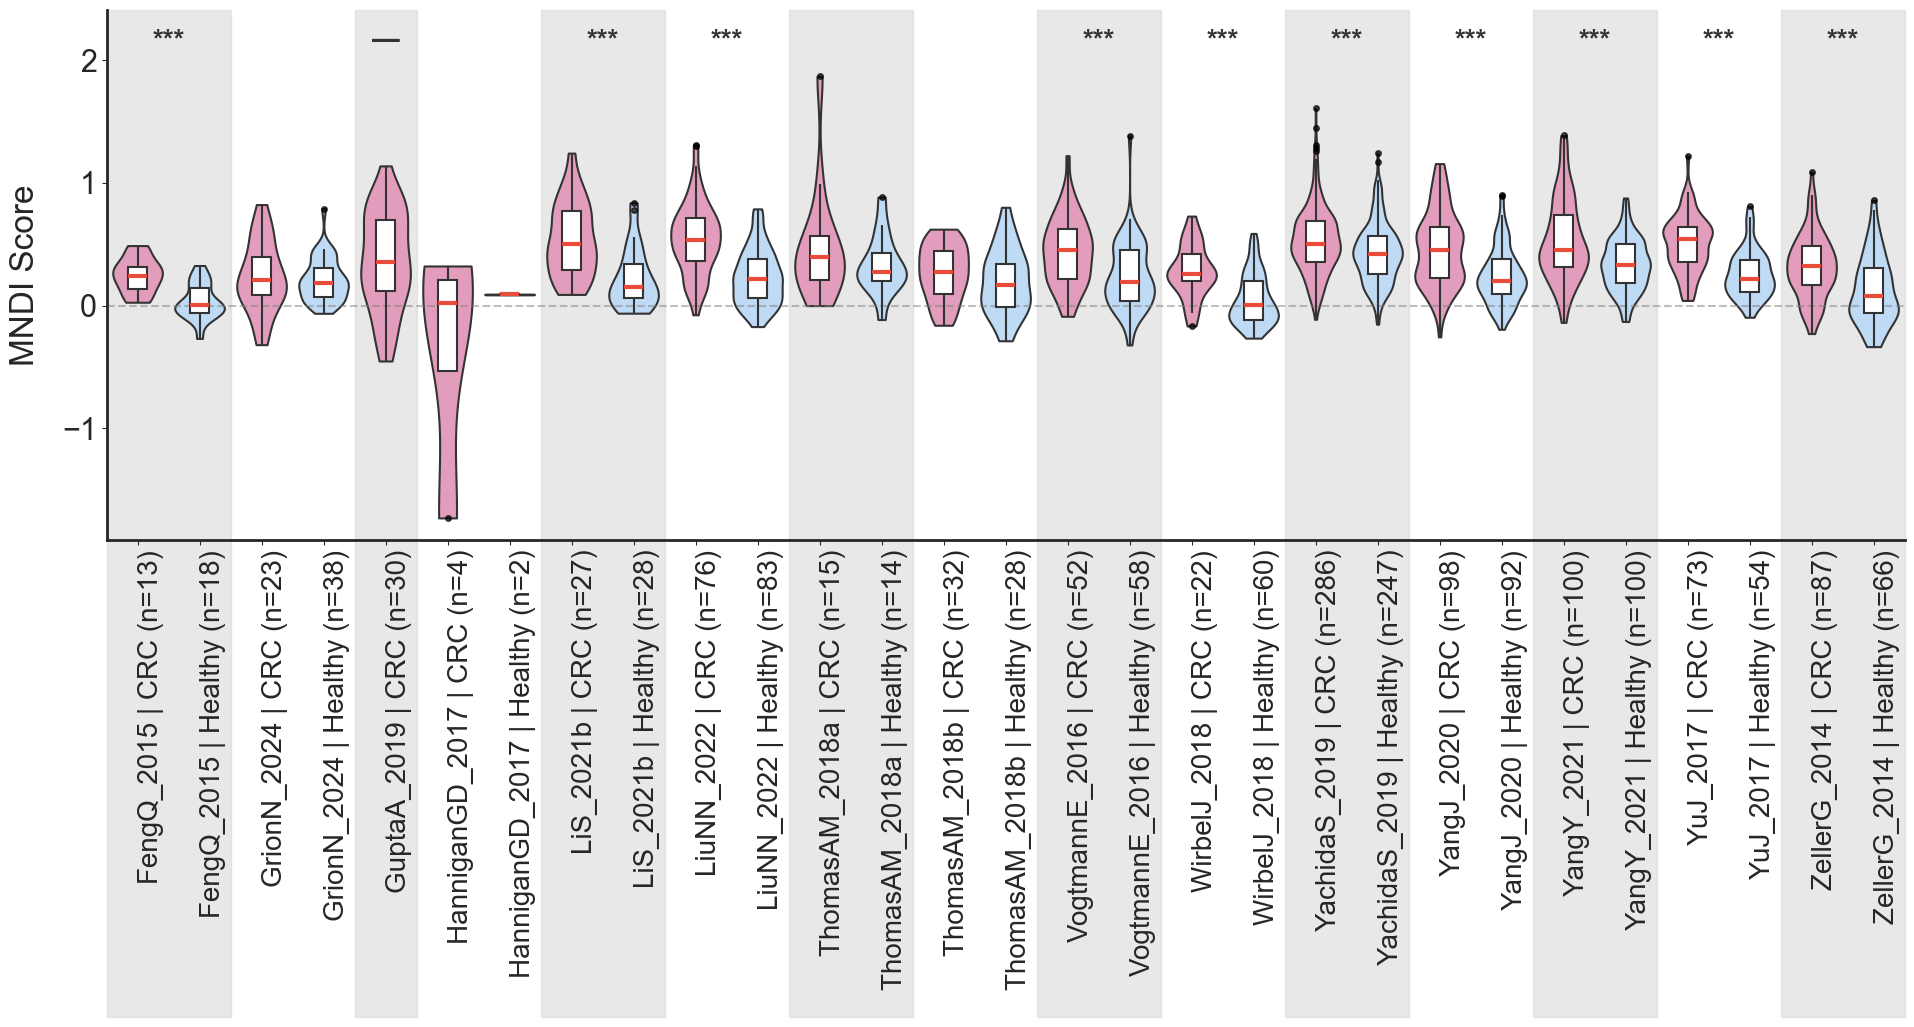

In [41]:
plot_hlevel_cohort_case_ctrl_mndi(df_features, label_df, 'CRC', '#ed91bb', '#b6dafd')

In [ ]:
# plot_cohort_case_ctrl_mndi(df_features, label_df, 'CRC', '#ed91bb', '#b6dafd')

In [29]:
def plot_cohort_case_ctrl_mndi(df_features, label_df, disease, case_color, ctrl_color):
    # --- 1. 数据整合与排序 ---
    label_df['sample_id'] = list(label_df.index)
    label_df['disease_united'] = ['Healthy' if i == 'healthy' else i for i in label_df['disease_united']]
    # 注意：确保 label_df 中包含 'disease_united' 列
    plot_df = pd.merge(df_features, label_df[['sample_id', 'project', 'disease_united']], on='sample_id', how='left')
    # 强制转换 group 为分类变量并指定顺序，这决定了同一项目内的上下顺序
    plot_df['group'] = pd.Categorical(plot_df['group'], categories=['case', 'ctrl'], ordered=True)
    # 计算样本量 (按 project 和 disease_united 分组)
    counts = plot_df.groupby(['project', 'disease_united']).size().reset_index(name='n')
    plot_df = pd.merge(plot_df, counts, on=['project', 'disease_united'])
    # --- 核心修改：构造 Y 轴标签 ---
    # 格式：Project | Disease (n=xx)
    plot_df['y_label'] = plot_df.apply(
        lambda x: f"{x['project']} | {x['disease_united']} (n={x['n']})", axis=1
    )
    # 排序：先按项目名排，再按 group 排 (确保 Case 在上面)
    plot_df = plot_df.sort_values(['project', 'group'])
    y_order = list(plot_df['y_label'].unique())
    projects = plot_df['project'].unique()
    # --- 2. 绘图初始化 ---
    fig, ax = plt.subplots(figsize=(12, len(y_order) * 0.7))
    plt.rc('font', size=22)
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['axes.linewidth'] = 2.0  # 全局设置边框粗细为 2.0
    plt.rcParams['pdf.fonttype'] = 42
    sns.set_style("ticks")
    # --- 核心修改：图例颜色映射 ---
    # 自动获取所有疾病名称并分配颜色（Healthy 用蓝色，其他疾病用不同色调的红色/橘色）
    unique_diseases = plot_df['disease_united'].unique()
    # color_map = {}
    # for d in unique_diseases:
    #     if 'healthy' in d.lower() or 'ctrl' in d.lower() or 'control' in d.lower():
    #         color_map[d] = '#b6dafd'  # 蓝色
    #     else:
    #         color_map[d] = '#ed91bb'  # 红色
    color_map = {}
    for label in y_order:
        # 根据 label_df 中的 group 分配颜色
        # 因为 y_label 是唯一的，我们可以反查这一行是 case 还是 ctrl
        current_group = plot_df[plot_df['y_label'] == label]['group'].iloc[0]
        if current_group == 'case':
            color_map[label] = case_color  # 红色
        else:
            color_map[label] = ctrl_color  # 蓝色
    # custom_palette = generate_random_colors(len(unique_diseases), seed=101)
    # --- 3. 绘制背景色块 ---
    trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)
    for i, proj in enumerate(projects):
        if i % 2 == 0:
            proj_labels = [label for label in y_order if label.startswith(proj)]
            indices = [y_order.index(l) for l in proj_labels]
            if indices:
                start_y, end_y = min(indices) - 0.5, max(indices) + 0.5
                rect = plt.Rectangle((-0.85, start_y), 1.85, end_y - start_y,
                                     transform=trans, color='lightgray', alpha=0.5,
                                     zorder=0, clip_on=False)
                ax.add_patch(rect)
    # --- 4. 绘制图形 (hue 使用 disease_united) ---
    # sns.boxplot(
    #     data=plot_df, x='MNDI', y='y_label', hue='disease_united',
    #     order=y_order, palette=color_map, dodge=False, width=0.6, fliersize=0, ax=ax, zorder=2
    # )
    # sns.stripplot(
    #     data=plot_df, x='MNDI', y='y_label', color='black',
    #     alpha=0.2, size=3, jitter=True, ax=ax, zorder=3
    # )
    # def filter_extreme(group):
    #     q_low = group['MNDI'].quantile(0.00001)  # 砍掉下限最极端的 1%
    #     q_high = group['MNDI'].quantile(0.99999) # 砍掉上限最极端的 1%
    #     return group[(group['MNDI'] >= q_low) & (group['MNDI'] <= q_high)]
    # 
    # violin_df = plot_df.groupby('y_label', group_keys=False).apply(filter_extreme)
    v = sns.violinplot(
        data=plot_df, x='MNDI', y='y_label', hue='y_label',
        order=y_order, palette=color_map, dodge=False, color='#333333',
        inner=None, linewidth=1.5, cut=0, ax=ax, zorder=2, legend=False, bw_adjust=0.8
    )
    for pc in v.collections:
        pc.set_edgecolor('#333333')  # 强制边框颜色
        pc.set_alpha(1)  # 确保边框是不透明的
    # 2. 叠加内部的迷你箱线图
    sns.boxplot(
        data=plot_df, x='MNDI', y='y_label',
        order=y_order, dodge=False,
        width=0.3,  # 🌟 把箱子调得很窄，刚好放在小提琴内部
        color='white',  # 箱体填充白色
        linewidth=1.5,  # 箱体外边框粗细
        fliersize=4,  # 隐藏离群点（避免和后面的散点图重复）
        flierprops={'marker': 'o', 'markerfacecolor': 'black', 'markeredgecolor': 'black', 'markersize': 4,
                    'alpha': 0.7},
        showcaps=False,  # 隐藏胡须末端的横线，使其更清爽
        ax=ax, zorder=3,
        boxprops={'edgecolor': '#333333'},  # 箱体边框颜色
        whiskerprops={'color': '#333333', 'linewidth': 1.5},  # 上下须的颜色和粗细
        medianprops={'color': '#a82315', 'linewidth': 3}  # 🌟 核心：中位线加粗！
    )
    # --- 5. P值计算与标注 ---
    x_max = plot_df['MNDI'].max()
    annotation_x = x_max +0.8
    
    stats_results = []
    
    for proj in projects:
        # 获取该项目所在行的索引，自动计算出正中间的 Y 坐标
        indices = [idx for idx, label in enumerate(y_order) if label.startswith(f"{proj} |")]
        if not indices: continue
        y_pos = sum(indices) / len(indices)
        
        # proj_data = plot_df[plot_df['project'] == proj]
        # case_vals = proj_data[proj_data['group'] == 'case']['MNDI']
        # ctrl_vals = proj_data[proj_data['group'] == 'ctrl']['MNDI']
        # # 默认缺组（没有Case或Ctrl）输出 '—'
        # stars = "—"
        # if len(case_vals) > 0 and len(ctrl_vals) > 0:
        #     stat, p_val = mannwhitneyu(case_vals, ctrl_vals)
        #     if p_val < 0.001:
        #         stars = '***'
        #     elif p_val < 0.01:
        #         stars = '**'
        #     elif p_val < 0.05:
        #         stars = '*'
        #     else:
        #         stars = ''  # 不显著就不标，或者你可以改成 'ns'
        # # 添加标注
        # if stars:
        #     ax.text(annotation_x, y_pos, stars, va='center', ha='center',
        #             fontsize=20, fontweight='bold', color='#333333')
        
        proj_data = plot_df[plot_df['project'] == proj]
        case_vals = proj_data[proj_data['group'] == 'case']['MNDI']
        ctrl_vals = proj_data[proj_data['group'] == 'ctrl']['MNDI']
        n_case = len(case_vals)
        n_ctrl = len(ctrl_vals)
        mndi_p_val = None
        shannon_p_val = None
        mndi_auc_val = None
        shannon_auc_val = None
        
        # 【改动 1-提取数据】: 提取对应的 Shannon 数据用于比对检验
        case_shannon = proj_data[proj_data['group'] == 'case']['shannon'].dropna()
        ctrl_shannon = proj_data[proj_data['group'] == 'ctrl']['shannon'].dropna()
        
        stars = "—"
        star_color = '#333333' # 默认星号颜色为黑色
        
        if len(case_vals) > 0 and len(ctrl_vals) > 0:
            stat, p_val = mannwhitneyu(case_vals, ctrl_vals)
            mndi_p_val = p_val
            y_true_mndi = [1] * n_case + [0] * n_ctrl
            y_score_mndi = list(case_vals) + list(ctrl_vals)
            fpr_m, tpr_m, _ = roc_curve(y_true_mndi, y_score_mndi)
            mndi_auc_val = auc(fpr_m, tpr_m)
            
            # 【改动 1-逻辑判定】: 如果各自 Shannon 样本量充足，做 Mann-Whitney U 检验
            if len(case_shannon) > 0 and len(ctrl_shannon) > 0:
                _, shannon_p = mannwhitneyu(case_shannon, ctrl_shannon)
                shannon_p_val = shannon_p
                y_true_shan = [1] * len(case_shannon) + [0] * len(ctrl_shannon)
                y_score_shan = list(case_shannon) + list(ctrl_shannon)
                fpr_s, tpr_s, _ = roc_curve(y_true_shan, y_score_shan)
                shannon_auc_val = auc(fpr_s, tpr_s)
                shannon_auc_val = max(shannon_auc_val, 1 - shannon_auc_val)
                # 若 MNDI 显著 (p<0.05) 且 Shannon 不显著 (p>=0.05)，星号标红
                if p_val < 0.05 and shannon_p >= 0.05:
                    star_color = '#a82315'
                elif p_val < shannon_p:
                    star_color = '#e74c3c'
            
            if p_val < 0.001:
                stars = '***'
            elif p_val < 0.01:
                stars = '**'
            elif p_val < 0.05:
                stars = '*'
            else:
                stars = ''  # ns
                
        # 添加标注 (颜色变更为动态的 star_color)
        if stars:
            ax.text(annotation_x, y_pos, stars, va='center', ha='center',
                    fontsize=20, fontweight='bold', color=star_color)
        stats_results.append({
            'project': proj,
            'n_case': n_case,
            'n_ctrl': n_ctrl,
            'MNDI_pvalue': mndi_p_val,
            'MNDI_AUC': mndi_auc_val,
            'Shannon_pvalue': shannon_p_val,
            'Shannon_AUC': shannon_auc_val
        })
    # --- 6. 美化与保存 ---
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    # plt.title('MNDI Distribution by Disease Type', fontsize=14, pad=20)
    ax.tick_params(axis='y', labelsize=22)  # 调节 Y 轴疾病标签的字体大小
    ax.tick_params(axis='x', labelsize=22)  # 调节 X 轴数字的字体大小
    plt.xlabel('MNDI Score', fontsize=24)
    plt.ylabel('')
    # --- 核心修改：自定义图例 ---
    # 手动创建两个代表 Disease 和 Healthy 的色块，颜色与你的前面设定的保持一致
    # disease_patch = mpatches.Patch(color='#e74c3c', label='Disease')
    # healthy_patch = mpatches.Patch(color='#3498db', label='Healthy')
    # # 覆盖默认图例
    # plt.legend(handles=[disease_patch, healthy_patch], title='Condition',
    #            bbox_to_anchor=(1.05, 1), loc='upper left')
    sns.despine()
    ax.xaxis.set_major_locator(MultipleLocator(1))
    plt.xlim(left=-2, right=annotation_x * 1.1)
    fig.subplots_adjust(left=0.35)  # 预留左侧空间
    save_path = f'/bgi-seq-model-2/codes/zhangkexin/meta_index/experiment/figures/finetune/11.25/networks/4.1/abs/new.{disease}.project.individual.case.ctrl.mndi.pdf'
    plt.savefig(save_path, dpi=800, bbox_inches='tight')
    plt.show()
    
    stats_df = pd.DataFrame(stats_results)
    csv_save_path = f'/bgi-seq-model-2/codes/zhangkexin/meta_index/experiment/figures/finetune/11.25/networks/4.1/abs/new.{disease}.project.individual.case.ctrl.project.stats1.tsv'
    stats_df.to_csv(csv_save_path, sep='\t', index=False)

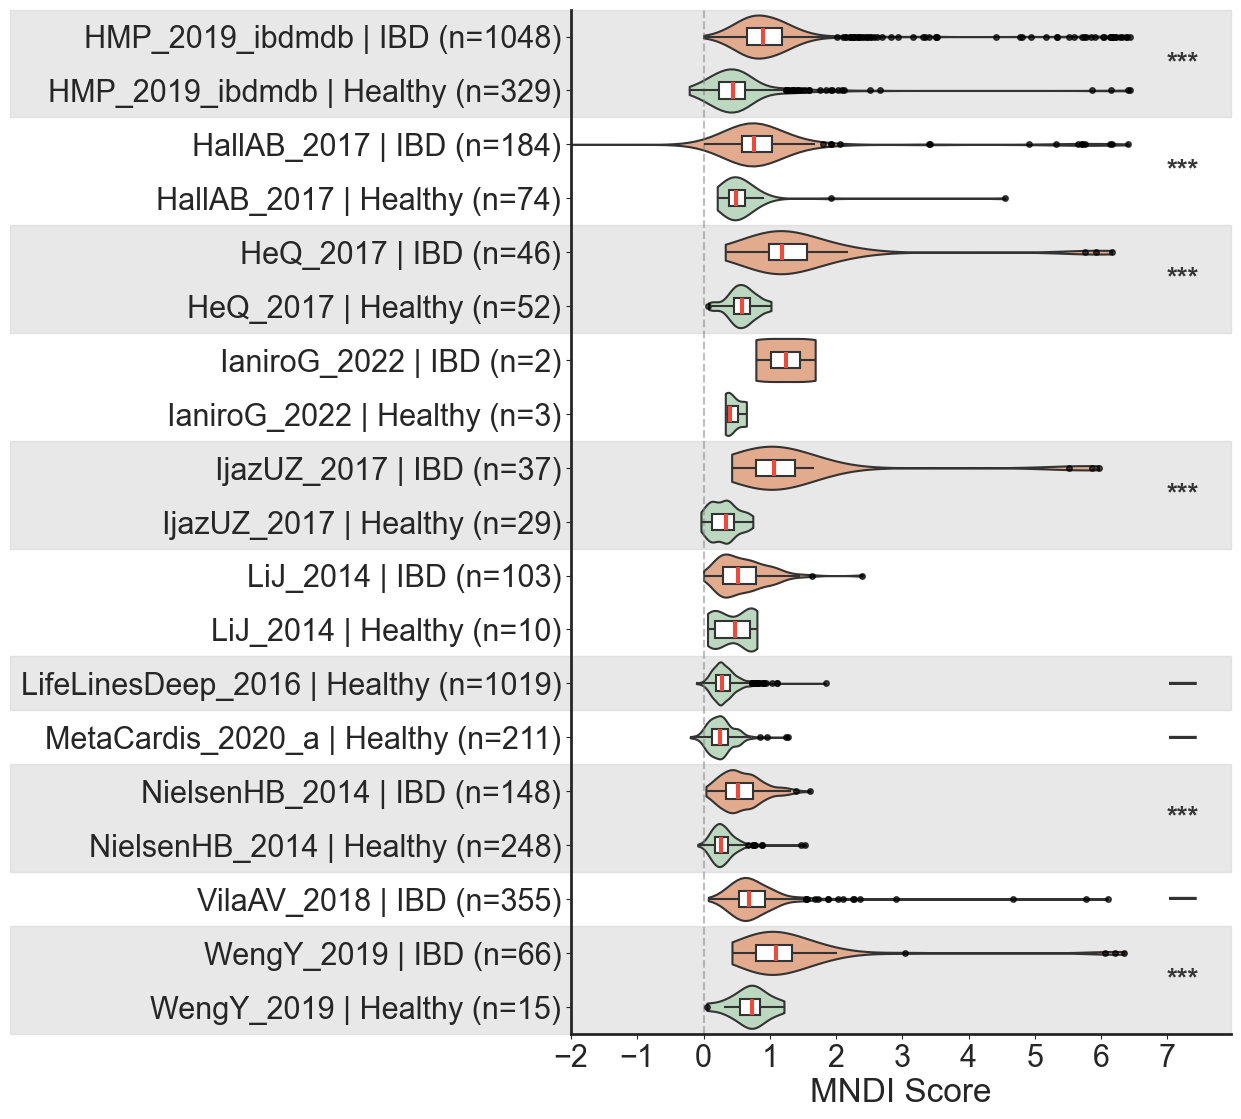

In [31]:

dir = '/bgi-seq-model-2/codes/zhangkexin/meta_index/experiment/results/network/1.8/ibd/'
individual_network = np.load(dir + 'ibd.pretrain.emb.individual.npy')
taxa2id = pickle.load(open(dir + 'ibd.pretrain.emb.individual.index.pkl', 'rb'))

ibd_biomarker = pd.read_csv(
    '/bgi-seq-model-2/codes/zhangkexin/meta_index/experiment/results/features/11.25/sort.multidisease.mean/IBD.biomarker.txt',
    sep='\t', header=None)
ibd_biomarker['weight.abs'] = ibd_biomarker[1].abs()
ibd_biomarker = ibd_biomarker.sort_values('weight.abs', ascending=False)
top_biomarker = list(ibd_biomarker[:30][0])  # 30
ibd_good_biomarker = list(ibd_biomarker[ibd_biomarker[1] < 0].iloc[:, 0])
ibd_bad_biomarker = list(ibd_biomarker[ibd_biomarker[1] > 0].iloc[:, 0])

sample_list = []
with open(dir + 'ibd.pretrain.emb.samples.list.txt', 'r') as f:
    for line in f.readlines():
        sample_list.append(line.strip())
label_df = pd.read_csv(
    '/bgi-seq-model-2/datasets/zhangkexin/meta_index/metaphlan4/fine-tune/curated_LiS_CRC_20204_v0908.train_test.phe',
    sep='\t', index_col=0)

label_df = label_df[~label_df['project'].isin(['IaniroG_2022', 'LiJ_2014', 'LifeLinesDeep_2016', 'MetaCardis_2020_a'])]

case_samples = []
ctrl_samples = []
for i in sample_list:
    if i in label_df.index:
        if label_df.loc[i, 'disease_united'] == 'IBD':
            case_samples.append(i)
        elif label_df.loc[i, 'disease_united'] == 'healthy':
            ctrl_samples.append(i)


df_features = calculate_mndi_v2(individual_network, sample_list, taxa2id,
                         case_samples, ctrl_samples,
                         ibd_bad_biomarker, ibd_good_biomarker)
# 加shannon
X_IBD = X.loc[case_samples+ctrl_samples, :]
shannon_df = pd.DataFrame({
    'sample_id': X_IBD.index,
    'shannon': X_IBD.apply(lambda x: entropy(x[x > 0]), axis=1)
})

df_features = pd.merge(df_features, shannon_df, on='sample_id', how='left')

plot_cohort_case_ctrl_mndi(df_features, label_df, 'IBD', '#F0A780', '#B8DDBC')